In [1]:
import os
import glob
import xarray as xr
import rioxarray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import datetime
import rasterio
import seaborn as sns
from shapely.geometry import box
from rasterio.enums import Resampling
import time
import gc
from scipy.stats import linregress

In [2]:
# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "etc"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

In [3]:
# --- 1. Fix the Automatic Band List (Ignore previous results) ---
main_folder = 'F://ETc'
required_bands = []
# Names of files we want to IGNORE as inputs
outputs_to_ignore = ["RHmin", "tvdi", "tvdi-all", "cwsi", "cwsi-all", "Kcb", "Ke", "Ks", "ETc", "ETp", "wdi", "RE"]
#outputs_to_ignore = ["wdi", "RE"]
i = 0
for subfolder in os.listdir(main_folder):
    sub_path = os.path.join(main_folder, subfolder)
    if not os.path.isdir(sub_path): continue
        
    for filename in os.listdir(sub_path):
        if filename.endswith(".tif"):
            img_name = filename.split('_')[0]
            # ONLY add to required_bands if it's NOT a result file
            if img_name not in outputs_to_ignore and img_name not in required_bands:
                required_bands.append(img_name)
    break # Only need to check one folder to get the list

In [4]:
required_bands

['ActVP',
 'Albedo',
 'B05',
 'B06',
 'B07',
 'B10',
 'B11',
 'B12',
 'B8A',
 'blue',
 'cwsi-all',
 'cwsi',
 'ETc',
 'ETo',
 'ETp',
 'green',
 'Kcb',
 'Ke',
 'Ks',
 'ndvi',
 'red',
 'RHmin',
 'RH',
 'RN-MJ',
 'SatVP',
 'SRad',
 'TMax',
 'TMin',
 'tvdi-all',
 'tvdi',
 'Wind']

# 1.	Basal Kc (𝐾𝑐𝑏) Estimation from Vegetation Indices for crop evapotranspiration

### Calculates RHmin using FAO Irrigation and Drainage Paper 56 (Allen et al., 1998).
##### RHmin = 100 * (ea/es(Tmax))
Allen, R. G., Pereira, L. P., Raes, D., Smith, M., 1998. Crop evapotranspiration - Guidelines for computing crop water requirements - FAO Irrigation and drainage paper 56. Chapter 4 - Determination of ETo.FAO - Food and Agriculture Organization of the United Nations. Rome, 1998. https://www.fao.org/4/x0490e/x0490e08.htm#chapter%204%20%20%20determination%20of%20eto

In [5]:
def calculate_RHmin(ds):
    # Calculate the saturation vapor pressure at the maximum temperature.
    es_tmax = 0.6108 * np.exp((17.27 * ds.TMax) / (ds.TMax + 237.3))
    RH_min = 100 * (ds.ActVP / es_tmax)
    return RH_min

### Calculates Kc,max and Kcb using (Phogat et al., 2016) and (Allen et al., 1998).
##### Kc,max=max(1.2+[0.04*(u2-2)-0.004*(RHmin-45)]*(h/3)0.3, (Kcb+0.05))
#### 𝐾𝑐𝑏=𝐾𝑐,𝑚𝑖𝑛+(𝐾𝑐,𝑚𝑎𝑥−𝐾𝑐,𝑚𝑖𝑛)*((𝑁𝐷𝑉𝐼−𝑁𝐷𝑉𝐼𝑚𝑖𝑛)/(𝑁𝐷𝑉𝐼𝑚𝑎𝑥−𝑁𝐷𝑉𝐼𝑚𝑖𝑛))
Allen, R. G., Pereira, L. P., Raes, D., Smith, M., 1998. Crop evapotranspiration - Guidelines for computing crop water requirements - FAO Irrigation and drainage paper 56. Chapter 7 - ETc - Dual crop coefficient (Kc = Kcb + Ke). FAO - Food and Agriculture Organization of the United Nations. Rome, 1998. https://www.fao.org/4/x0490e/x0490e0c.htm#chapter%207%20%20%20etc%20%20%20dual%20crop%20coefficient%20(kc%20=%20kcb%20+%20ke)

Phogat, V., Šimůnek, J., Skewes, M.A., Cox, J.W., McCarthy, M.G., 2016. Improving the estimation of evaporation by the FAO-56 dual crop coefficient approach under subsurface drip irrigation. Agricultural Water Management. Volume 178, December 2016, Pages 189-200. https://doi.org/10.1016/j.agwat.2016.09.022.

In [6]:
def calculate_Kcb(ds, RH_min, ndvi_min, ndvi_max):
    # 1. Create a spatial height map based on NDVI
    h_max_expected = 1.2  # Adjust based on the local knowledge of East Delta crops
    h_min_expected = 0.05
    h_map = h_min_expected + (h_max_expected - h_min_expected) * \
            ((ds.ndvi - ndvi_min) / (ndvi_max - ndvi_min))
    h_map = h_map.where(h_map > h_min_expected, h_min_expected) # Clamp min height
    
    # 2. Calculate Climate-Adjusted Kc_max (for Kcb calculation)
    # Note: (h/3)**0.3 is the FAO-56 standard aerodynamic adjustment
    kc_max_clim = 1.2 + (0.04 * (ds.Wind - 2) - 0.004 * (RH_min - 45)) * (h_map / 3)**0.3
    
    # 3. Calculate Kcb
    kcb = 0.15 + (kc_max_clim - 0.15) * ((ds.ndvi - ndvi_min) / (ndvi_max - ndvi_min))
    
    # 4. Calculate Final Kc_max for Ke (The "Buffer" step)
    kc_max_final = xr.where(kc_max_clim > (kcb + 0.05), kc_max_clim, kcb + 0.05)

    return kcb, kc_max_final

# 2.	The soil evaporation coefficient (𝐾𝑒) Estimation

A function for calculating the dry and wet edges from LST and NDVI.

In [7]:
def calculate_dynamic_edges(lst, ndvi):
    """
    Finds the Dry Edge and Wet Edge from the LST-NDVI scatter plot.
    Input: xarray DataArrays (masked to agricultural land only)
    """
    # 1. Flatten arrays and remove NaNs (this includes the Sea/Urban mask)
    lst_flat = lst.values.flatten()
    ndvi_flat = ndvi.values.flatten()
    
    mask = ~np.isnan(lst_flat) & ~np.isnan(ndvi_flat)
    lst_clean = lst_flat[mask]
    ndvi_clean = ndvi_flat[mask]

    # 2. Divide NDVI into bins (e.g., 0.05 increments) to find max/min LST per bin
    bins = np.arange(0, 1.05, 0.05)
    max_lst_per_bin = []
    min_lst_per_bin = []
    valid_ndvi_centers = []

    for i in range(len(bins)-1):
        idx = (ndvi_clean >= bins[i]) & (ndvi_clean < bins[i+1])
        if np.sum(idx) > 50:  # Ensure enough pixels for a statistical sample
            # Use 95th and 5th percentile to avoid outlier noise (sensor errors)
            max_lst_per_bin.append(np.percentile(lst_clean[idx], 95))
            min_lst_per_bin.append(np.percentile(lst_clean[idx], 5))
            valid_ndvi_centers.append((bins[i] + bins[i+1]) / 2)

    # 3. Linear Regression to find the Edges
    # Dry Edge: LST_max = a + b * NDVI
    slope_dry, intercept_dry, _, _, _ = linregress(valid_ndvi_centers, max_lst_per_bin)
    
    # Wet Edge: LST_min = a + b * NDVI (often a horizontal line, but can slope)
    slope_wet, intercept_wet, _, _, _ = linregress(valid_ndvi_centers, min_lst_per_bin)

    return (slope_dry, intercept_dry), (slope_wet, intercept_wet)

### Calculate Kr, few, Ke,max, and Ke
##### 𝑇𝑉𝐷𝐼=(𝐿𝑆𝑇−𝐿𝑆𝑇𝑚𝑖𝑛)/(𝐿𝑆𝑇𝑚𝑎𝑥−𝐿𝑆𝑇𝑚𝑖𝑛)
##### Kr = 1 - TVDI

##### 𝐾𝑒,𝑚𝑎𝑥=𝑚𝑖𝑛(𝐾𝑐,𝑚𝑎𝑥−𝐾𝑐𝑏,𝑖,𝑓𝑒𝑤,𝑖*𝐾𝑐,𝑚𝑎𝑥)
##### 𝑓𝑒𝑤=𝑚𝑖𝑛(1, (1−𝑓𝑐,))
##### 𝑓𝑐,𝑖=((𝑁𝐷𝑉𝐼𝑖−𝑁𝐷𝑉𝐼𝑚𝑖𝑛)/(𝑁𝐷𝑉𝐼𝑚𝑎𝑥−𝑁𝐷𝑉𝐼𝑚𝑖𝑛))2
fc used the power of regarding to:
Bhaskar J Choudhury, Synergism of multispectral satellite observations for estimating regional land surface evaporation, Remote Sensing of Environment, Volume 49, Issue 3, 1994, Pages 264-274, ISSN 0034-4257, https://doi.org/10.1016/0034-4257(94)90021-3.
##### Ke = Kr * Ke,max
Allen, R. G., Pereira, L. P., Raes, D., Smith, M., 1998. Crop evapotranspiration - Guidelines for computing crop water requirements - FAO Irrigation and drainage paper 56. Chapter 7 - ETc - Dual crop coefficient (Kc = Kcb + Ke). FAO - Food and Agriculture Organization of the United Nations. Rome, 1998. https://www.fao.org/4/x0490e/x0490e0c.htm#chapter%207%20%20%20etc%20%20%20dual%20crop%20coefficient%20(kc%20=%20kcb%20+%20ke)

Phogat, V., Šimůnek, J., Skewes, M.A., Cox, J.W., McCarthy, M.G., 2016. Improving the estimation of evaporation by the FAO-56 dual crop coefficient approach under subsurface drip irrigation. Agricultural Water Management. Volume 178, December 2016, Pages 189-200. https://doi.org/10.1016/j.agwat.2016.09.022.

In [8]:
def calculate_Ke(ds, lst, kcb, kc_max_final, lst_max_edge, lst_min_edge, ndvi_min, ndvi_max):
    # 1. Calculate TVDI and Kr (Soil Evaporation Factor)
    tvdi = (lst - lst_min_edge) / (lst_max_edge - lst_min_edge)
    tvdi = tvdi.clip(0, 1) # Ensure no values outside 0-1
    kr = 1 - tvdi

    # 2. Get dynamic min/max (using 5nd/95th percentile to avoid outliers for robustness)
    # fc is calculated according to Choudhury, B. J., et al. (1994).
    # few is the exposed soil fraction min(1, 1-fc)
    fc = ((ds.ndvi - ndvi_min) / (ndvi_max - ndvi_min))**2
    few = (1 - fc).clip(max=1)

    # 3. Calculate Ke_max (using the final buffer)
    ke_max = xr.where((kc_max_final - kcb) < (few * kc_max_final), 
                      (kc_max_final - kcb), 
                      (few * kc_max_final))

    # 4. Calculate Ke
    ke = kr * ke_max

    return tvdi, ke

# 3.	Water Stress Coefficient (Ks) Estimation

### Calculate ΔT, CWSI, and Ks
##### CWSI = [((Ts - Ta) – (Ts - Ta)ll) / ((Ts - Ta)ul – (Ts - Ta)ll)]
##### ΔT = Ts – Ta
##### 𝐾𝑠=1−𝐶𝑊𝑆𝐼
Emily G. Kullberg, Kendall C. DeJonge, José L. Chávez, Evaluation of thermal remote sensing indices to estimate crop evapotranspiration coefficients, Agricultural Water Management, Volume 179, 2017, Pages 64-73, ISSN 0378-3774, https://doi.org/10.1016/j.agwat.2016.07.007.

Abia Katimbo, Daran R. Rudnick, Kendall C. DeJonge, Tsz Him Lo, Xin Qiao, Trenton E. Franz, Hope Njuki Nakabuye, Jiaming Duan, Crop water stress index computation approaches and their sensitivity to soil water dynamics, Agricultural Water Management, Volume 266, 2022, 107575,
ISSN 0378-3774, https://doi.org/10.1016/j.agwat.2022.107575.

Ciężkowski, W., Szporak-Wasilewska, S., Kleniewska, M., Jóźwiak, J., Gnatowski, T., Dąbrowski, P., Góraj, M., Szatyłowicz, J., Ignar, S., & Chormański, J. (2020). Remotely Sensed Land Surface Temperature-Based Water Stress Index for Wetland Habitats. Remote Sensing, 12(4), 631. https://doi.org/10.3390/rs12040631

Bian, J., Zhang, Z., Chen, J., Chen, H., Cui, C., Li, X., Chen, S., & Fu, Q. (2019). Simplified Evaluation of Cotton Water Stress Using High Resolution Unmanned Aerial Vehicle Thermal Imagery. Remote Sensing, 11(3), 267. https://doi.org/10.3390/rs11030267

Hui Chen, Hongxing Chen, Song Zhang, Shengxi Chen, Fulang Cen, Quanzhi Zhao, Xiaoyun Huang, Tengbing He, Zhenran Gao, Comparison of CWSI and Ts-Ta-VIs in moisture monitoring of dryland crops (sorghum and maize) based on UAV remote sensing, Journal of Integrative Agriculture, Volume 23, Issue 7, 2024, Pages 2458-2475, ISSN 2095-3119, https://doi.org/10.1016/j.jia.2024.03.042.

In [9]:
def calculate_Ks(ds, lst, ndvi, threshold=0.3):
    # --- CWSI FOR Ks (Plant Stress) ---
    # Calculate Delta T (LST - T_air)
    # Note: T_air here is the T_avg, which is the closest air temperature to the thermal one at 10:30 AM estimate.
    T_avg = (ds.TMax + ds.TMin) / 2
    delta_t = lst - T_avg
    
    # If threshold is None, calculate limits for the whole map (for AI)
    if threshold is not None:
        veg_delta_t = delta_t.where(ndvi > threshold)
    else:
        veg_delta_t = delta_t # Use all pixels
    dt_ll = float(veg_delta_t.quantile(0.05, skipna=True).compute()) # Wet crop
    dt_ul = float(veg_delta_t.quantile(0.95, skipna=True).compute()) # Stressed crop
    
    cwsi = (delta_t - dt_ll) / (dt_ul - dt_ll)
    cwsi = cwsi.clip(0, 1)
    ks = 1 - cwsi

    return cwsi, ks

# 4. Crop Evapotranspiration (ETc)

### Calculate the Crop Evapotranspiration (ETc)
##### ETC = (Kcb . Ks + Ke) ETo
Allen, R. G., Pereira, L. P., Raes, D., Smith, M., 1998. Crop evapotranspiration - Guidelines for computing crop water requirements - FAO Irrigation and drainage paper 56. Chapter 7 - ETc - Dual crop coefficient (Kc = Kcb + Ke). FAO - Food and Agriculture Organization of the United Nations. Rome, 1998. https://www.fao.org/4/x0490e/x0490e0c.htm#chapter%207%20%20%20etc%20%20%20dual%20crop%20coefficient%20(kc%20=%20kcb%20+%20ke)

Phogat, V., Šimůnek, J., Skewes, M.A., Cox, J.W., McCarthy, M.G., 2016. Improving the estimation of evaporation by the FAO-56 dual crop coefficient approach under subsurface drip irrigation. Agricultural Water Management. Volume 178, December 2016, Pages 189-200. https://doi.org/10.1016/j.agwat.2016.09.022.

In [10]:
def calculate_ETc(ds, kcb, ks, ke):
    etc = (kcb * ks + ke) * ds.ETo   # Actual Evapotranspiration
    etp = (kcb + ke) * ds.ETo    # Potential Evapotranspiration

    return etc, etp

### Load geoimages per date
#### Create a Helper to Find the "Correct" File
##### Since your filenames have different suffixes (_mas, _rep_mas), we need a flexible way to find them.

In [11]:
def find_band_file(subfolder_path, band_name):
    """Search for a specific band file regardless of suffixes."""
    for f in os.listdir(subfolder_path):
        # Checks if file starts with band (e.g., B02) and is a .tif
        if f.startswith(band_name) and f.endswith(".tif"):
            return os.path.join(subfolder_path, f)
    return None

In [12]:
# Fetch the Land Use map to mask only the agricultural areas.
lulc = rioxarray.open_rasterio('images/etc/rf_20230806.tif').squeeze()

### The Main Processing Loop
##### It loops through dates, loads the bands into a single object, and runs the previous functions.

In [13]:
master_band_name = 'red'

In [14]:
for date_folder in os.listdir(main_folder):
    subfolder_path = os.path.join(main_folder, date_folder)
    if not os.path.isdir(subfolder_path): continue

    # --- NEW CHECK: SKIP IF ALREADY DONE ---
    final_output_check = os.path.join(subfolder_path, f"wdi_{date_folder}.tif")
    if os.path.exists(final_output_check):
        print(f"⏩ Skipping {date_folder}: Output already exists.")
        continue
    
    print(f"🚀 Processing: {date_folder}")

    # 1. Load the Master Band (The 10m grid, everything should follow)
    master_path = find_band_file(subfolder_path, master_band_name)
    if not master_path: continue
    # masked=True turns 0 into NaN immediately. This stops the "Millions" error.
    master_grid = rioxarray.open_rasterio(master_path, masked=True).squeeze().astype('float32')
    # Clean the master grid to ensure it acts as a valid mask
    master_grid = master_grid.where(master_grid > 0)

    # 2. Load all required bands into a dictionary
    band_data_dict = {}
    for band in required_bands:
        file_path = find_band_file(subfolder_path, band)
        if file_path:
            # Masked=True is key to preventing the "Millions" error from NoData
            da = rioxarray.open_rasterio(file_path, masked=True).squeeze().astype('float32')
            # resampling=1 (Bilinear) is essential for smooth weather data (9.8m -> 10m)
            band_data_dict[band] = da.rio.reproject_match(master_grid, resampling=1)
        else:
            print(f"Warning: Missing {band} for {date_folder}")

    # 3. Combine the dictionary into a single xarray Dataset
    if len(band_data_dict) == len(required_bands):
        ds = xr.Dataset(band_data_dict).astype('float32')

        # Align LU map to the current date's resolution and extent
        lulc_matched = lulc.rio.reproject_match(master_grid, resampling=0)

        # 4. Create the Agricultural Mask
        # This creates a boolean mask where True = Agriculture
        agri_mask = (lulc_matched == 1)

        # 5. Apply the mask to NDVI and LST
        # We use .where() to keep data where agri_mask is True, others become NaN
        ds['ndvi_masked'] = ds.ndvi.where(agri_mask)
        ds['lst_masked'] = ds.B10.where(agri_mask)
        
        # 6. Now, use these 'masked' versions for your Quantiles and Edges!
        ndvi_min = float(ds.ndvi_masked.quantile(0.05, skipna=True).compute())
        ndvi_max = float(ds.ndvi_masked.quantile(0.95, skipna=True).compute())
        
        # 7. Apply the functions
        RHmin_map = calculate_RHmin(ds)
        kcb_map, kc_max_final_map = calculate_Kcb(ds, RHmin_map, ndvi_min, ndvi_max)
        # Developed maps after masking only the agricultural land
        # Get the dry and wet edges for the agricultral masked map
        (slope_d, inter_d), (slope_w, inter_w) = calculate_dynamic_edges(ds.lst_masked, ds.ndvi_masked)
        # Calculate the Max/Min LST theoretical limits for every pixel based on its NDVI
        lst_max_edge = inter_d + slope_d * ds.ndvi_masked
        lst_min_edge = inter_w + slope_w * ds.ndvi_masked
        tvdi_map, ke_map = calculate_Ke(ds, ds.lst_masked, kcb_map, kc_max_final_map, lst_max_edge, lst_min_edge, ndvi_min, ndvi_max)
        cwsi_map, ks_map = calculate_Ks(ds, ds.lst_masked, ds.ndvi_masked, threshold=0.3)
        # Getting the indices TVDI and CSWI for the all AOI regardless the agricultural land
        # Get the dry and wet edges for the agricultral masked map
        (slope_d, inter_d), (slope_w, inter_w) = calculate_dynamic_edges(ds.B10, ds.ndvi)
        # Calculate the Max/Min LST theoretical limits for every pixel based on its NDVI
        lst_max_edge = inter_d + slope_d * ds.ndvi
        lst_min_edge = inter_w + slope_w * ds.ndvi
        tvdi_all_map, _ = calculate_Ke(ds, ds.B10, kcb_map, kc_max_final_map, lst_max_edge, lst_min_edge, ndvi_min, ndvi_max)
        cwsi_all_map, _ = calculate_Ks(ds, ds.B10, ds.ndvi, threshold=None)
        # Calculate the final ETc and ETp
        etc_map, etp_map = calculate_ETc(ds, kcb_map, ks_map, ke_map)

        # --- SAFETY CLAMP ---
        # Any ETc value outside 0-1.4 from ETo values (using 1.4 as a safety margin for high-transpiring crops)mm is likely an error from bad input pixels
        etc_map = etc_map.where((etc_map > 0) & (etc_map < ds.ETo * 1.5))
        etp_map = etp_map.where((etp_map > 0) & (etp_map < ds.ETo * 1.5))

        # 8. Calculate the water dificit and the Relative Evapotranspiration
        # Water Deficit Index (WDI) for water stress mapping to Identifies drought "hotspots" in the Delta.
        # WDI = Potential ET - Actual ET (which contain the soil stressor)
        wdi_map = (etp_map - etc_map).clip(min=0)
        # Relative Evapotranspiration "dimensionless ratio ( 0 to 1) that tells "What is the health and performance level of this crop compared to its full potential?"Best Use Case: Comparing fields with different crop types or growth stages.
        # Relative Evapotranspiration or Crop Water Satisfaction Index = Actual ET / Potential ET
        re_map = (etc_map / etp_map).clip(0, 1)

        # Put the results in a dictionary
        results = {
            "RHmin": RHmin_map,
            "tvdi": tvdi_map,
            "tvdi-all": tvdi_all_map,
            "cwsi": cwsi_map,
            "cwsi-all": cwsi_all_map,
            "Kcb": kcb_map,
            "Ke": ke_map,
            "Ks": ks_map,
            "ETc": etc_map,
            "ETp": etp_map,
            "wdi": wdi_map,
            "RE": re_map
            
        }
        
        # 5. "Match" the metadata to be safe (copies CRS and Transform from the original dataset) and saving the results
        for name, data in results.items():
            data = data.rio.write_crs(ds.rio.crs)
            out_path = os.path.join(subfolder_path, f"{name}_{date_folder}.tif")
            data.rio.to_raster(out_path, driver="GTiff", dtype="float32", compress="lzw", tiled=True)
            print(f"Successfully saved: {out_path}")

        # Clear specific large objects from memory
        results.clear()
        del ds, RHmin_map, tvdi_map, tvdi_all_map, cwsi_map, cwsi_all_map, kcb_map, ke_map, ks_map, etc_map, etp_map, wdi_map, re_map, slope_d, inter_d, slope_w, inter_w, lst_max_edge, lst_min_edge, ndvi_min, ndvi_max, lulc_matched, results
        # Force Python to release the RAM back to the OS
        gc.collect()
    else:
        print(f"Skipping {date_folder} due to missing bands.")
    
    # 1. Clear the dictionary contents first
    band_data_dict.clear() 
    # 2. Delete the dictionary and the master grid
    del band_data_dict, master_grid
    # 3. Final call to the garbage collector
    gc.collect()

🚀 Processing: 2023-07-14
Successfully saved: F://ETc\2023-07-14\wdi_2023-07-14.tif
Successfully saved: F://ETc\2023-07-14\RE_2023-07-14.tif
🚀 Processing: 2023-07-22
Successfully saved: F://ETc\2023-07-22\wdi_2023-07-22.tif
Successfully saved: F://ETc\2023-07-22\RE_2023-07-22.tif
🚀 Processing: 2023-08-07
Successfully saved: F://ETc\2023-08-07\wdi_2023-08-07.tif
Successfully saved: F://ETc\2023-08-07\RE_2023-08-07.tif
🚀 Processing: 2023-08-31
Successfully saved: F://ETc\2023-08-31\wdi_2023-08-31.tif
Successfully saved: F://ETc\2023-08-31\RE_2023-08-31.tif
🚀 Processing: 2023-09-08
Successfully saved: F://ETc\2023-09-08\wdi_2023-09-08.tif
Successfully saved: F://ETc\2023-09-08\RE_2023-09-08.tif
🚀 Processing: 2024-06-14
Successfully saved: F://ETc\2024-06-14\wdi_2024-06-14.tif
Successfully saved: F://ETc\2024-06-14\RE_2024-06-14.tif
🚀 Processing: 2024-06-22
Successfully saved: F://ETc\2024-06-22\wdi_2024-06-22.tif
Successfully saved: F://ETc\2024-06-22\RE_2024-06-22.tif
🚀 Processing: 2024-0

 ##### Calculate the average values for the whole AoI per date.

In [4]:
stats_list = []

for date_folder in os.listdir(main_folder):
    sub_path = os.path.join(main_folder, date_folder)
    if not os.path.isdir(sub_path):
        continue

    # Define paths for both results
    eto_path = os.path.join(sub_path, f"ETo_{date_folder}.tif")
    etc_path = os.path.join(sub_path, f"ETc_{date_folder}.tif")
    etp_path = os.path.join(sub_path, f"ETp_{date_folder}.tif")
    tvdi_path = os.path.join(sub_path, f"tvdi_{date_folder}.tif")
    cwsi_path = os.path.join(sub_path, f"cwsi_{date_folder}.tif")
    kcb_path = os.path.join(sub_path, f"kcb_{date_folder}.tif")
    ke_path = os.path.join(sub_path, f"ke_{date_folder}.tif")
    ks_path = os.path.join(sub_path, f"ks_{date_folder}.tif")
    wdi_path = os.path.join(sub_path, f"wdi_{date_folder}.tif")
    re_path = os.path.join(sub_path, f"RE_{date_folder}.tif")
    
    # We only process if BOTH files exist
    if os.path.exists(eto_path) and os.path.exists(etc_path):
        try:
            # Open lazily (chunks=True prevents memory spikes)
            eto_da = rioxarray.open_rasterio(eto_path, chunks=True).squeeze()
            etc_da = rioxarray.open_rasterio(etc_path, chunks=True).squeeze()
            etp_da = rioxarray.open_rasterio(etp_path, chunks=True).squeeze()
            tvdi_da = rioxarray.open_rasterio(tvdi_path, chunks=True).squeeze()
            cwsi_da = rioxarray.open_rasterio(cwsi_path, chunks=True).squeeze()
            kcb_da = rioxarray.open_rasterio(kcb_path, chunks=True).squeeze()
            ke_da = rioxarray.open_rasterio(ke_path, chunks=True).squeeze()
            ks_da = rioxarray.open_rasterio(ks_path, chunks=True).squeeze()
            wdi_da = rioxarray.open_rasterio(wdi_path, chunks=True).squeeze()
            re_da = rioxarray.open_rasterio(re_path, chunks=True).squeeze()
            
            # Calculate means
            # skipna=True is vital in case your AoI has jagged edges or clouds
            m_eto = float(eto_da.mean(skipna=True).compute())
            m_etc = float(etc_da.mean(skipna=True).compute())
            m_etp = float(etp_da.mean(skipna=True).compute())
            m_tvdi = float(tvdi_da.mean(skipna=True).compute())
            m_cwsi = float(cwsi_da.mean(skipna=True).compute())
            m_kcb = float(kcb_da.mean(skipna=True).compute())
            m_ke = float(ke_da.mean(skipna=True).compute())
            m_ks = float(ks_da.mean(skipna=True).compute())
            m_wdi = float(wdi_da.mean(skipna=True).compute())
            m_re = float(re_da.mean(skipna=True).compute())
            
            stats_list.append({
                "Date": date_folder, 
                "Mean_ETo_mm": round(m_eto, 3), 
                "Mean_ETc_mm": round(m_etc, 3),
                "Mean_ETp_mm": round(m_etp, 3),
                "Mean_TVDI": round(m_tvdi, 3),
                "Mean_CWSI": round(m_cwsi, 3),
                "Mean_Kcb": round(m_kcb, 3),
                "Mean_Ke": round(m_ke, 3),
                "Mean_Ks": round(m_ks, 3),
                "Mean_WDI": round(m_wdi, 3),
                "Mean_RE": round(m_re, 3)
            })
            
            print(f"✅ {date_folder}: ETo={m_eto:.2f}, ETc={m_etc:.2f}, ETp={m_etp:.2f}, TVDI={m_tvdi:.2f}, CWSI={m_cwsi:.2f}, Kcb={m_kcb:.2f}, Ke={m_ke:.2f}, Ks={m_ks:.2f}, WDI={m_wdi:.2f}, RE={m_re:.2f}")
            
        except Exception as e:
            print(f"❌ Error reading {date_folder}: {e}")
        finally:
            # Clear memory handle
            del eto_da, etc_da, etp_da, tvdi_da, cwsi_da, kcb_da, ke_da, ks_da, wdi_da, re_da
            gc.collect()

✅ 2023-07-14: ETo=7.74, ETc=6.64, ETp=9.31, TVDI=0.40, CWSI=0.41, Kcb=0.67, Ke=0.16, Ks=0.59, WDI=2.78, RE=0.67
✅ 2023-07-22: ETo=7.12, ETc=6.11, ETp=8.17, TVDI=0.38, CWSI=0.39, Kcb=0.26, Ke=0.18, Ks=0.61, WDI=2.15, RE=0.72
✅ 2023-08-07: ETo=6.83, ETc=6.05, ETp=8.55, TVDI=0.36, CWSI=0.39, Kcb=0.68, Ke=0.10, Ks=0.61, WDI=2.58, RE=0.67
✅ 2023-08-31: ETo=5.60, ETc=4.63, ETp=6.68, TVDI=0.33, CWSI=0.43, Kcb=0.68, Ke=0.14, Ks=0.57, WDI=2.10, RE=0.65
✅ 2023-09-08: ETo=7.60, ETc=6.28, ETp=8.69, TVDI=0.40, CWSI=0.49, Kcb=0.40, Ke=0.25, Ks=0.51, WDI=2.55, RE=0.68
✅ 2024-06-14: ETo=6.43, ETc=4.61, ETp=6.72, TVDI=0.47, CWSI=0.53, Kcb=0.68, Ke=0.25, Ks=0.47, WDI=2.22, RE=0.63
✅ 2024-06-22: ETo=7.68, ETc=5.79, ETp=8.38, TVDI=0.46, CWSI=0.50, Kcb=0.71, Ke=0.25, Ks=0.50, WDI=2.73, RE=0.64
✅ 2024-07-08: ETo=6.88, ETc=5.57, ETp=8.10, TVDI=0.43, CWSI=0.44, Kcb=0.84, Ke=0.15, Ks=0.56, WDI=2.63, RE=0.65
✅ 2024-07-24: ETo=7.01, ETc=5.84, ETp=8.42, TVDI=0.40, CWSI=0.42, Kcb=0.70, Ke=0.13, Ks=0.58, WDI=2.66, 

### Creating a Comparison Table

In [5]:
# Create the DataFrame
df = pd.DataFrame(stats_list)
# CONVERT TO DATETIME (Crucial for a clean timeline)
df['Date'] = pd.to_datetime(df['Date'])
# Sort by date to make sure the plot follows the timeline
df = df.sort_values('Date')
# Convert back to string format for the X-axis to remove the "winter gap"
date_labels = df['Date'].dt.strftime('%Y-%m-%d').tolist()
# Save to CSV so you can use it in Excel for your paper
df.to_csv('Eto_Etc_Temporal_Comparison.csv', index=False)

df

,Date,Mean_ETo_mm,Mean_ETc_mm,Mean_ETp_mm,Mean_TVDI,Mean_CWSI,Mean_Kcb,Mean_Ke,Mean_Ks,Mean_WDI,Mean_RE
0,2023-07-14,7.738,6.638,9.310,0.398,0.411,0.672,0.158,0.589,2.778,0.674
1,2023-07-22,7.124,6.109,8.169,0.382,0.392,0.261,0.181,0.608,2.148,0.719
2,2023-08-07,6.830,6.048,8.547,0.357,0.388,0.680,0.103,0.612,2.576,0.674
3,2023-08-31,5.602,4.634,6.680,0.332,0.427,0.679,0.136,0.573,2.105,0.652
4,2023-09-08,7.605,6.278,8.694,0.397,0.489,0.404,0.247,0.511,2.555,0.684
5,2024-06-14,6.427,4.615,6.724,0.471,0.528,0.679,0.247,0.472,2.217,0.626
6,2024-06-22,7.684,5.788,8.375,0.456,0.504,0.710,0.249,0.496,2.725,0.642
7,2024-07-08,6.883,5.567,8.102,0.427,0.439,0.841,0.154,0.561,2.626,0.651
8,2024-07-24,7.006,5.842,8.423,0.400,0.422,0.698,0.131,0.578,2.664,0.656
9,2024-08-01,6.517,5.492,7.891,0.400,0.411,0.706,0.114,0.589,2.473,0.659


In [3]:
# Load the saved data
df = pd.read_csv('Eto_Etc_Temporal_Comparison.csv')
df

,Date,Mean_ETo_mm,Mean_ETc_mm,Mean_ETp_mm,Mean_TVDI,Mean_CWSI,Mean_Kcb,Mean_Ke,Mean_Ks,Mean_WDI,Mean_RE
0,2023-07-14,7.738,6.638,9.310,0.398,0.411,0.672,0.158,0.589,2.778,0.674
1,2023-07-22,7.124,6.109,8.169,0.382,0.392,0.261,0.181,0.608,2.148,0.719
2,2023-08-07,6.830,6.048,8.547,0.357,0.388,0.680,0.103,0.612,2.576,0.674
3,2023-08-31,5.602,4.634,6.680,0.332,0.427,0.679,0.136,0.573,2.105,0.652
4,2023-09-08,7.605,6.278,8.694,0.397,0.489,0.404,0.247,0.511,2.555,0.684
5,2024-06-14,6.427,4.615,6.724,0.471,0.528,0.679,0.247,0.472,2.217,0.626
6,2024-06-22,7.684,5.788,8.375,0.456,0.504,0.710,0.249,0.496,2.725,0.642
7,2024-07-08,6.883,5.567,8.102,0.427,0.439,0.841,0.154,0.561,2.626,0.651
8,2024-07-24,7.006,5.842,8.423,0.400,0.422,0.698,0.131,0.578,2.664,0.656
9,2024-08-01,6.517,5.492,7.891,0.400,0.411,0.706,0.114,0.589,2.473,0.659


### Visualizing Trends

#### Plotting mean values

Saving figure ETc_time_series


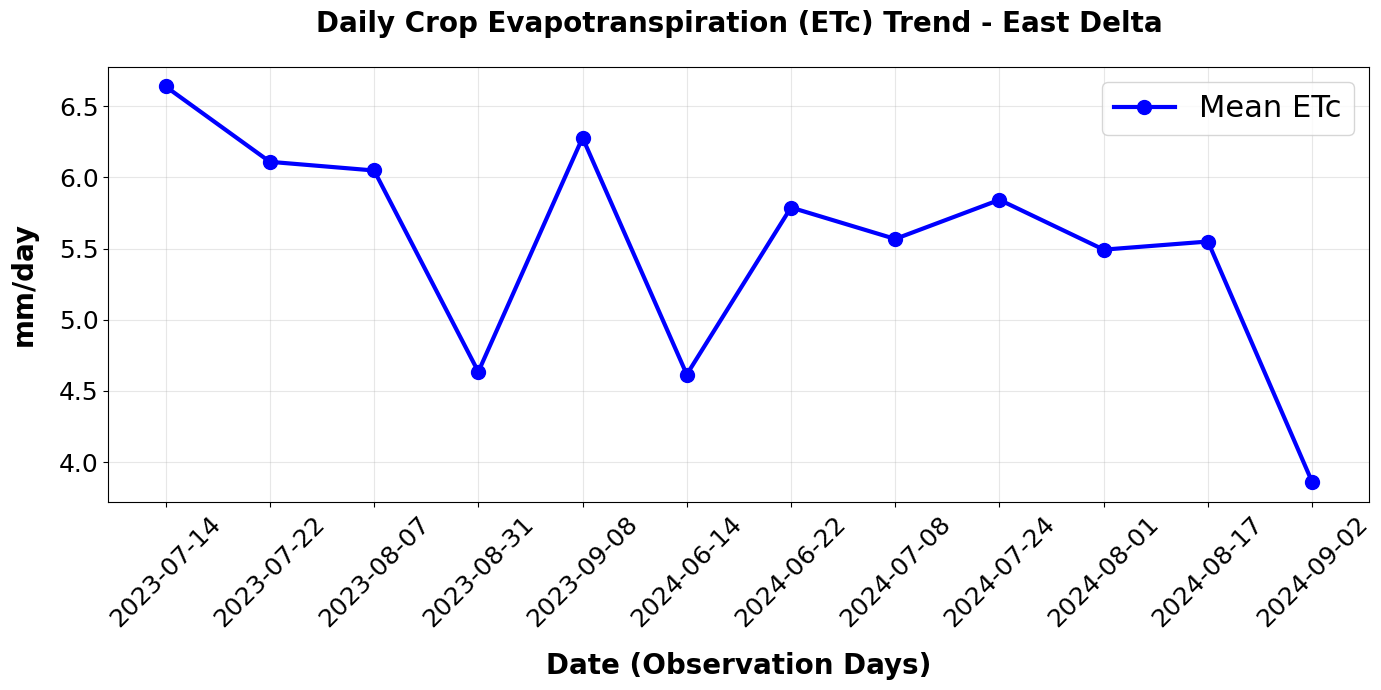

In [30]:
# A time-series line plot for ETc
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_ETc_mm'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean ETc')
plt.title('Daily Crop Evapotranspiration (ETc) Trend - East Delta', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('mm/day', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("ETc_time_series")
plt.show()

Saving figure ETp_time_series


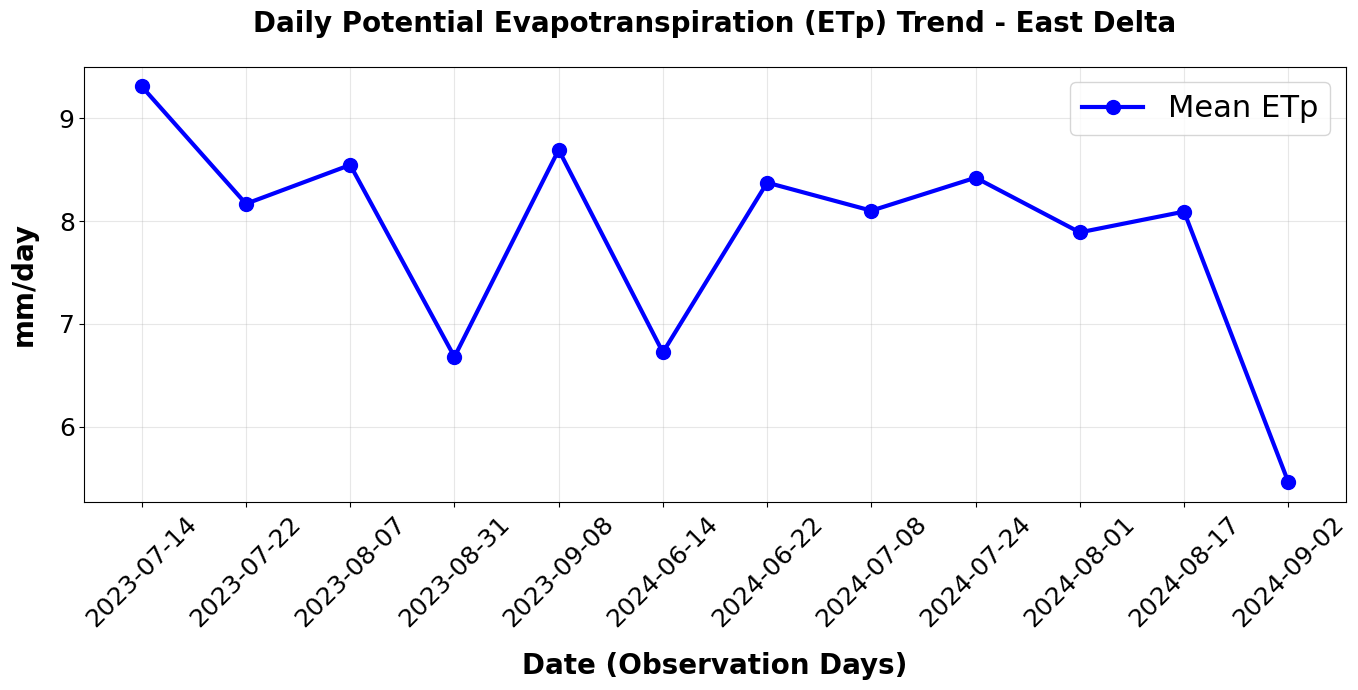

In [29]:
# A time-series line plot for ETc
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_ETp_mm'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean ETp')
plt.title('Daily Potential Evapotranspiration (ETp) Trend - East Delta', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('mm/day', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("ETp_time_series")
plt.show()

Saving figure TVDI_time_series


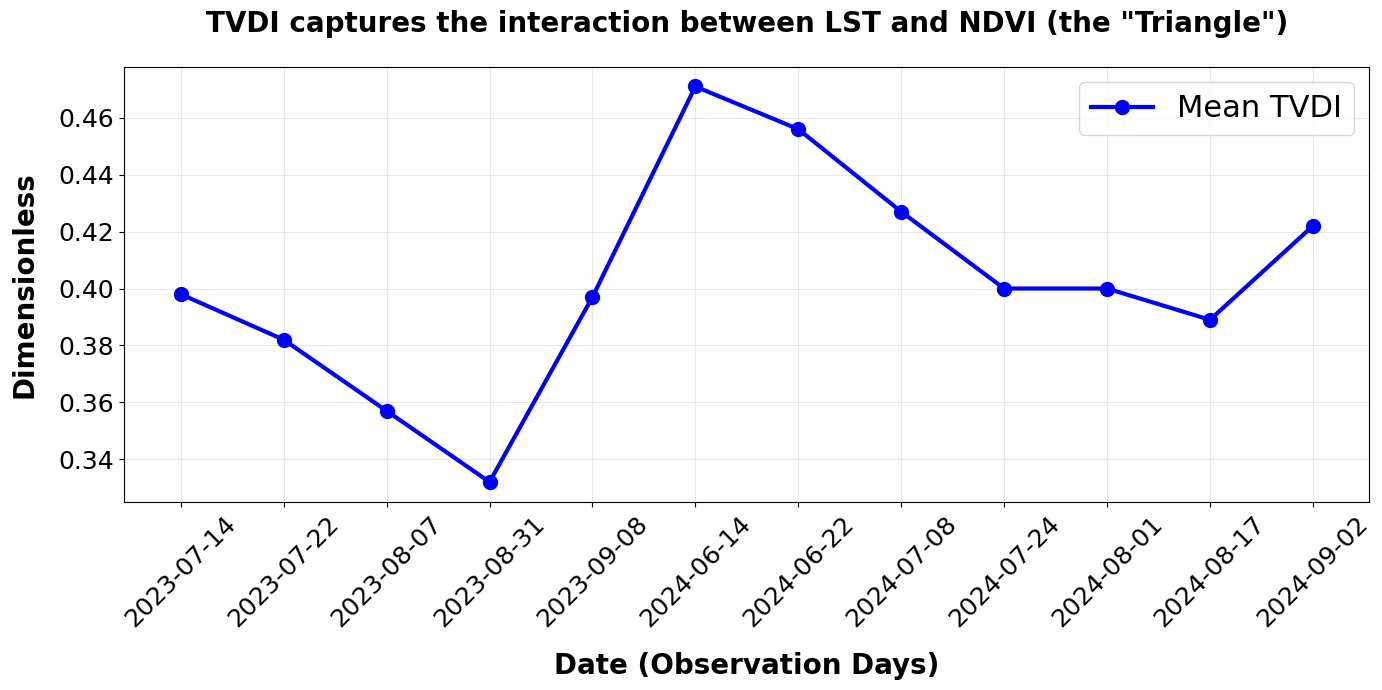

In [6]:
# A time-series line plot for TVDI
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_TVDI'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean TVDI')
plt.title('TVDI captures the interaction between LST and NDVI (the "Triangle")', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Dimensionless', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("TVDI_time_series")
plt.show()

Saving figure CWSI_time_series


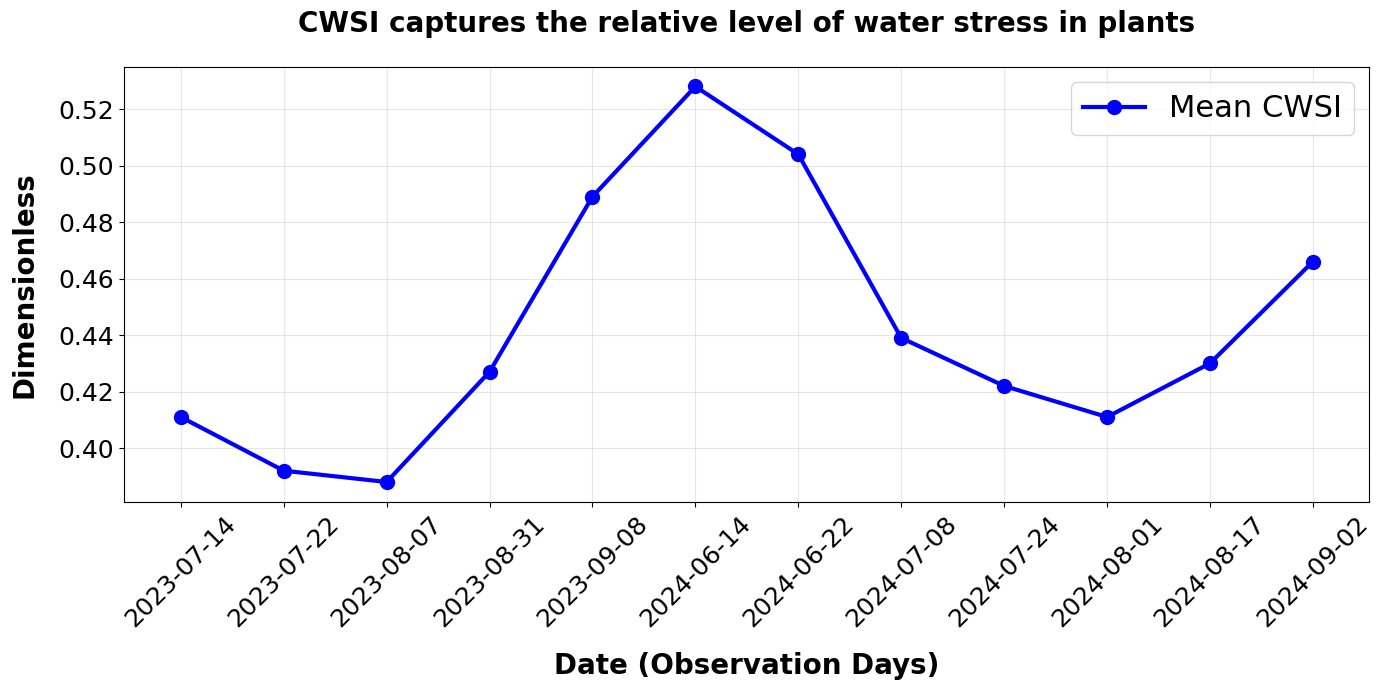

In [7]:
# A time-series line plot for CWSI
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_CWSI'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean CWSI')
plt.title('CWSI captures the relative level of water stress in plants', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Dimensionless', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("CWSI_time_series")
plt.show()

Saving figure Kcb_time_series


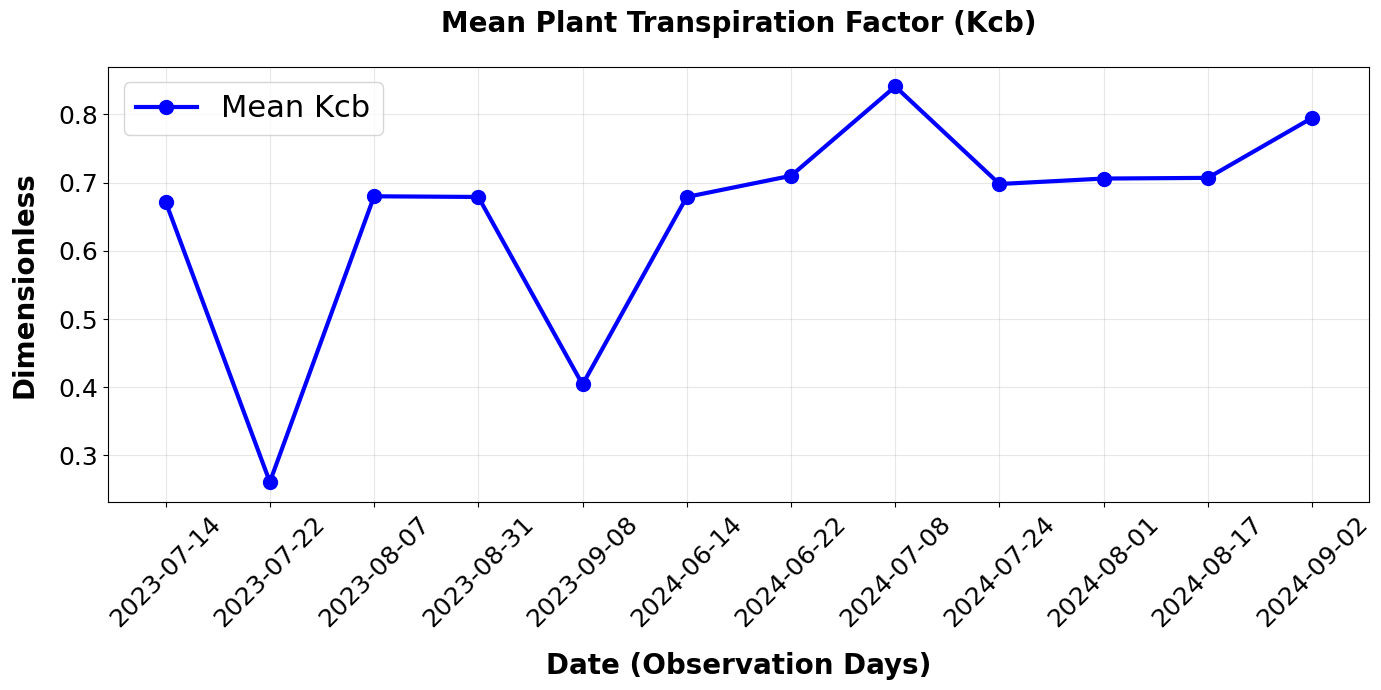

In [8]:
# A time-series line plot for Kcb
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_Kcb'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean Kcb')
plt.title('Mean Plant Transpiration Factor (Kcb)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Dimensionless', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("Kcb_time_series")
plt.show()

Saving figure Ke_time_series


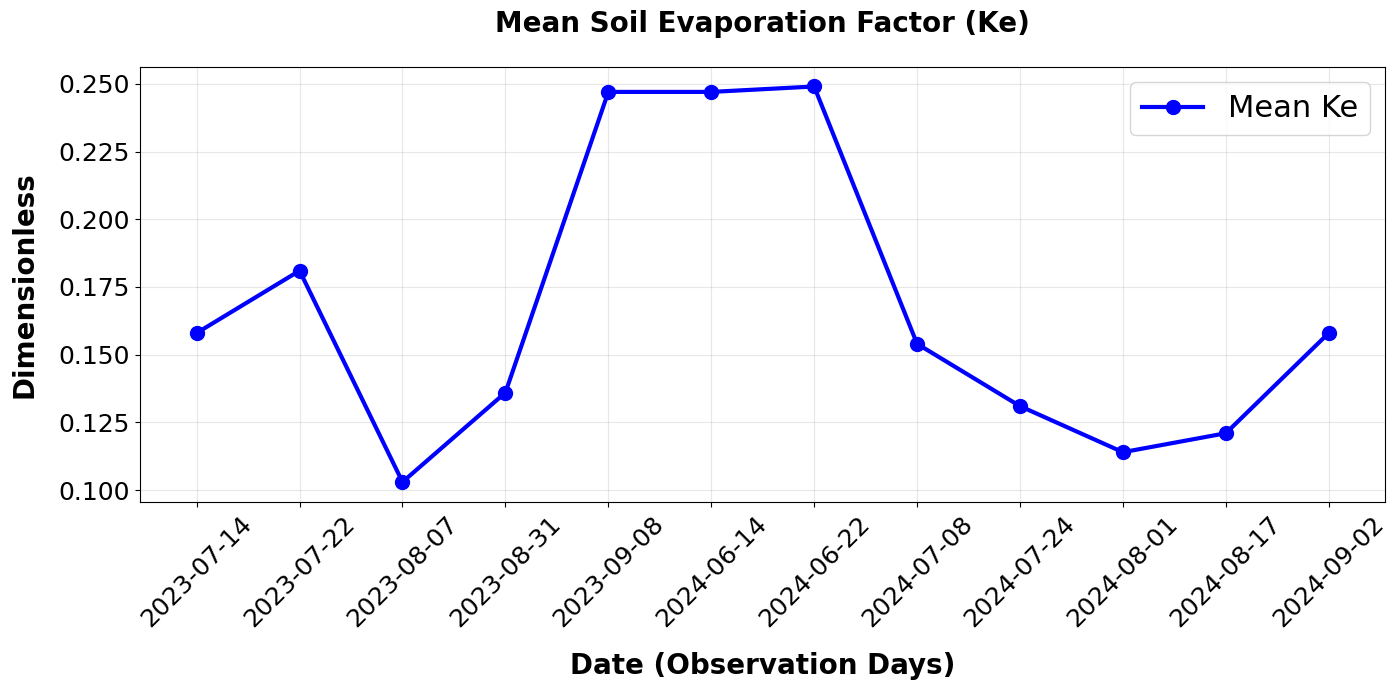

In [9]:
# A time-series line plot for Ke
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_Ke'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean Ke')
plt.title('Mean Soil Evaporation Factor (Ke)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Dimensionless', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("Ke_time_series")
plt.show()

Saving figure Ks_time_series


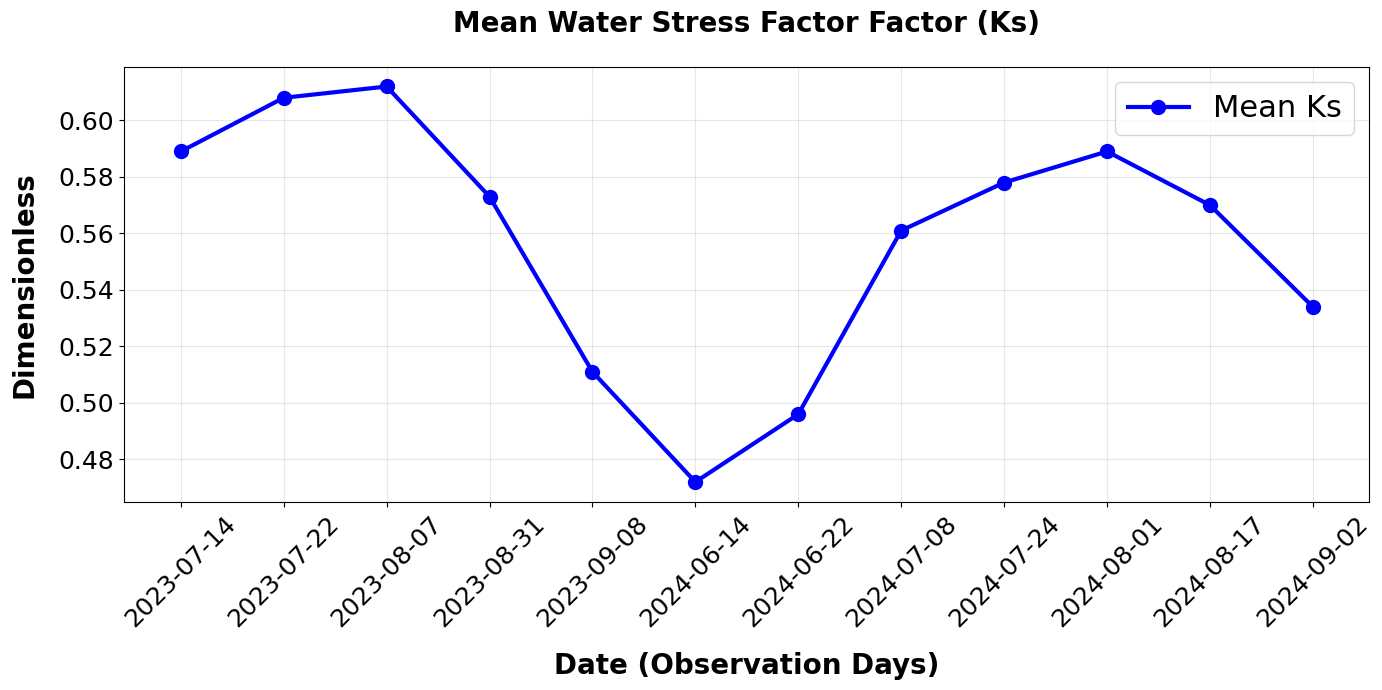

In [10]:
# A time-series line plot for Ks
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_Ks'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean Ks')
plt.title('Mean Water Stress Factor Factor (Ks)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Dimensionless', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("Ks_time_series")
plt.show()

Saving figure WDI_time_series


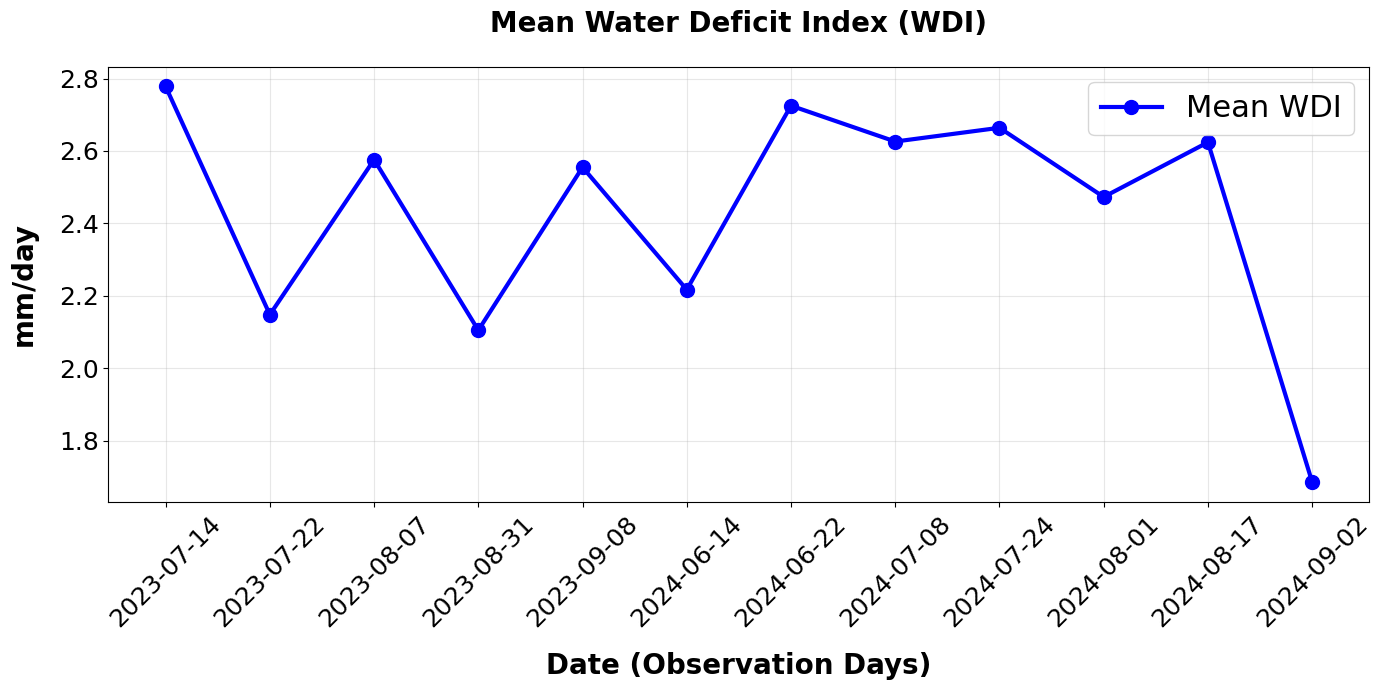

In [11]:
# A time-series line plot for WDI
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_WDI'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean WDI')
plt.title('Mean Water Deficit Index (WDI)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('mm/day', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("WDI_time_series")
plt.show()

Saving figure RE_time_series


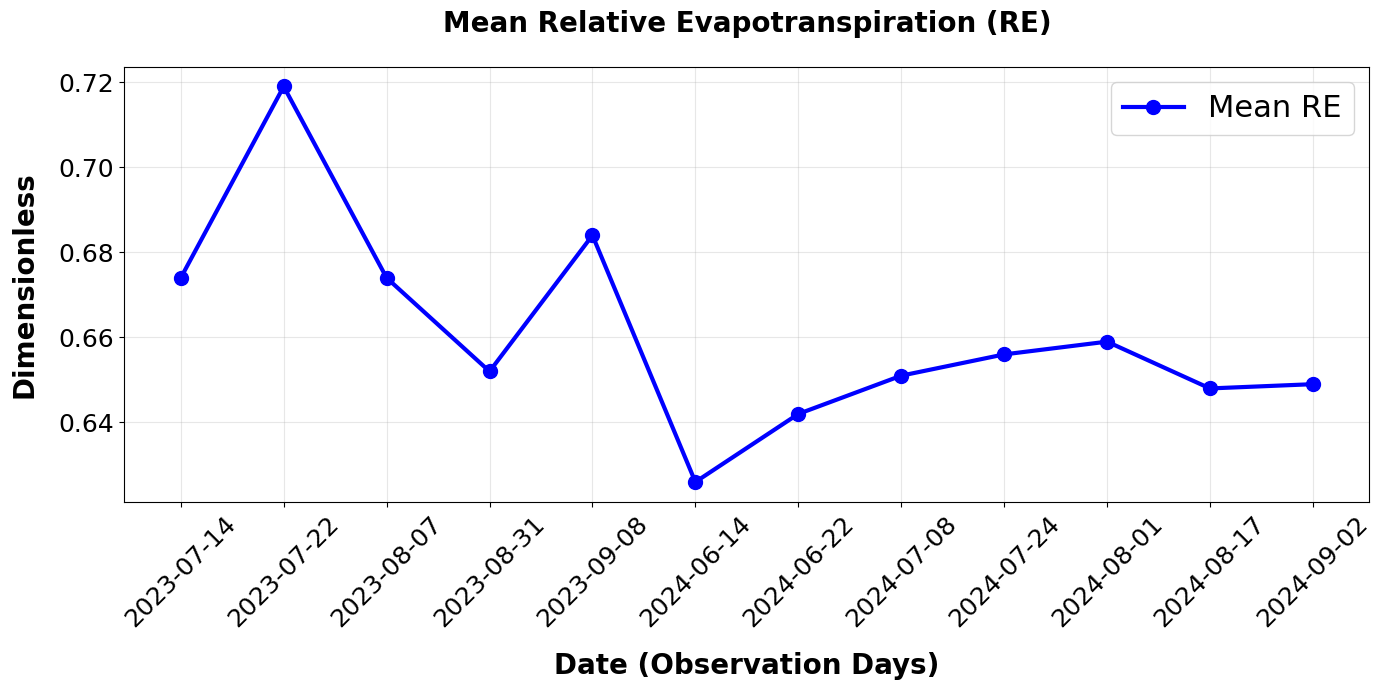

In [12]:
# A time-series line plot for RE
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_RE'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean RE')
plt.title('Mean Relative Evapotranspiration (RE)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Dimensionless', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("RE_time_series")
plt.show()

#### Comparisons between mean values

Saving figure ETo_ETc_Comparison


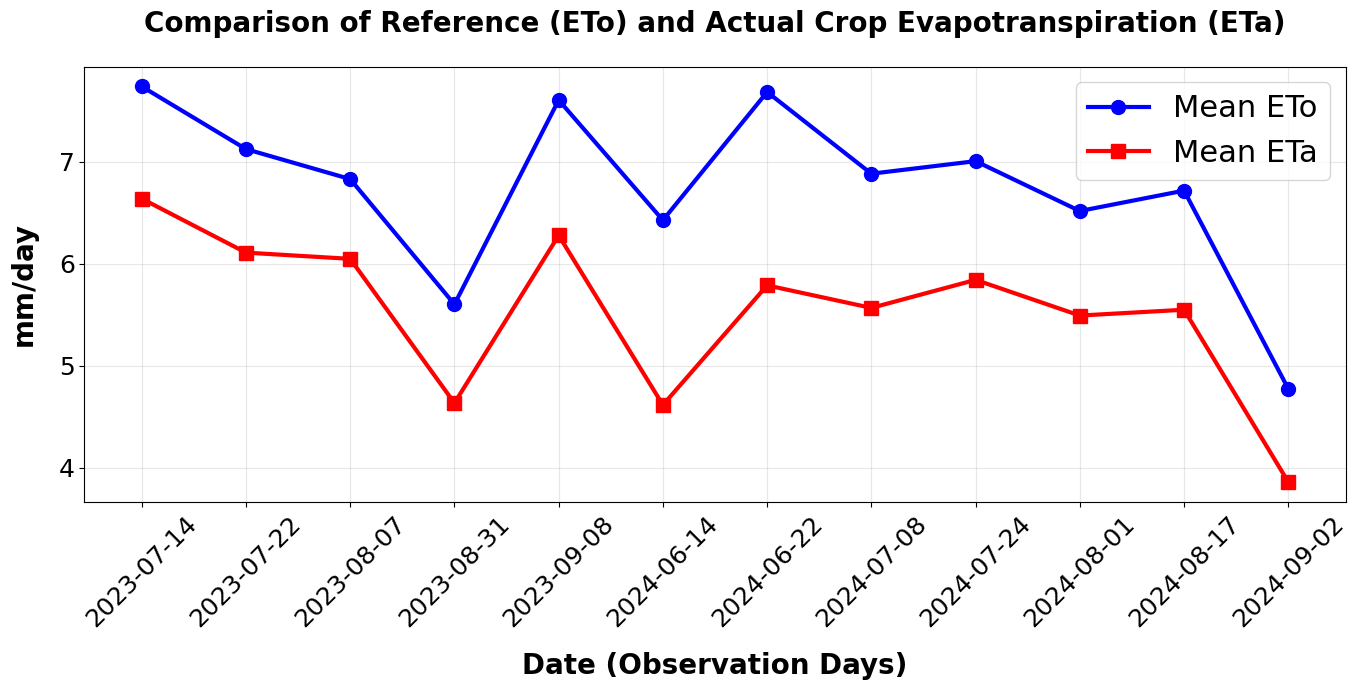

In [13]:
# A time-series line plot for comparison between ETo and ETc
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_ETo_mm'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean ETo')
plt.plot(df['Date'], df['Mean_ETc_mm'], marker='s', markersize=10, linestyle='-', color='red', linewidth=3, label='Mean ETa')
plt.title('Comparison of Reference (ETo) and Actual Crop Evapotranspiration (ETa)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('mm/day', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("ETo_ETc_Comparison")
plt.show()

Saving figure ETp_ETc_Comparison


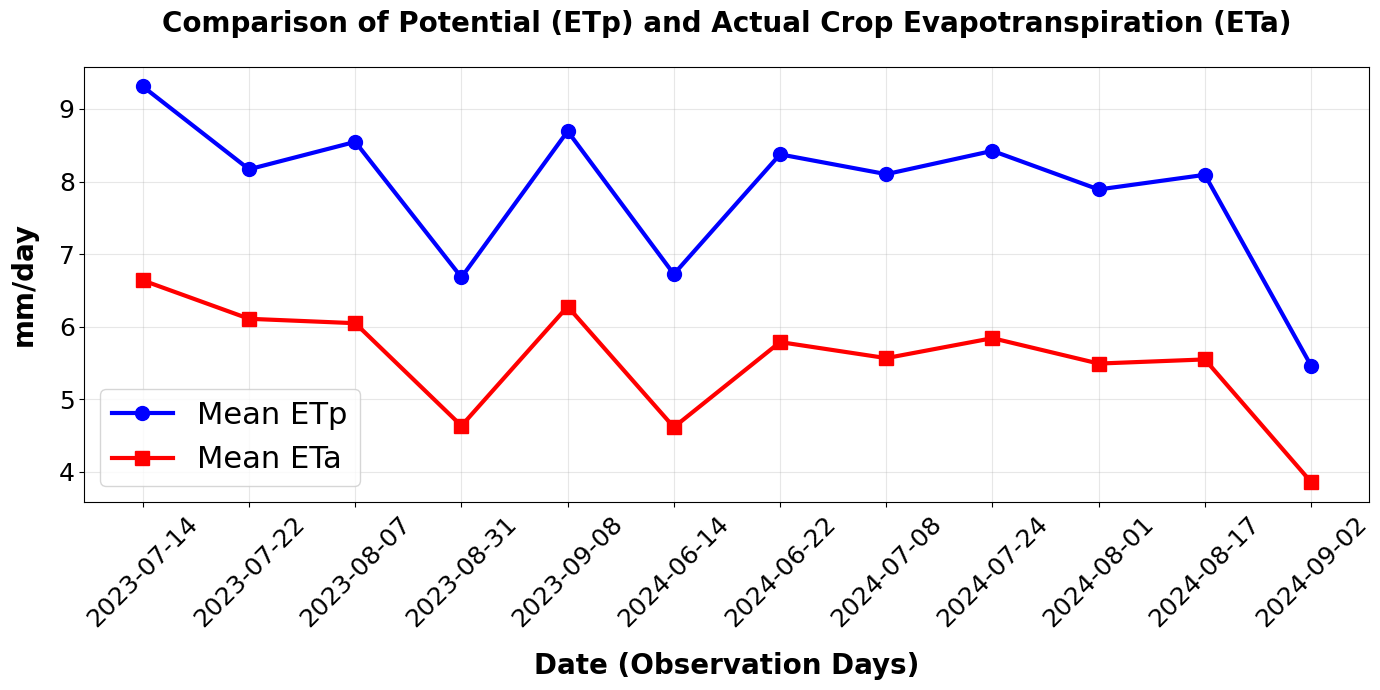

In [8]:
# A time-series line plot for comparison between ETp and ETc
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_ETp_mm'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean ETp')
plt.plot(df['Date'], df['Mean_ETc_mm'], marker='s', markersize=10, linestyle='-', color='red', linewidth=3, label='Mean ETa')
plt.title('Comparison of Potential (ETp) and Actual Crop Evapotranspiration (ETa)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('mm/day', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=22)
plt.xticks(rotation=45)
save_fig("ETp_ETc_Comparison")
plt.show()

Saving figure ETo_ETc_ETp_Comparison


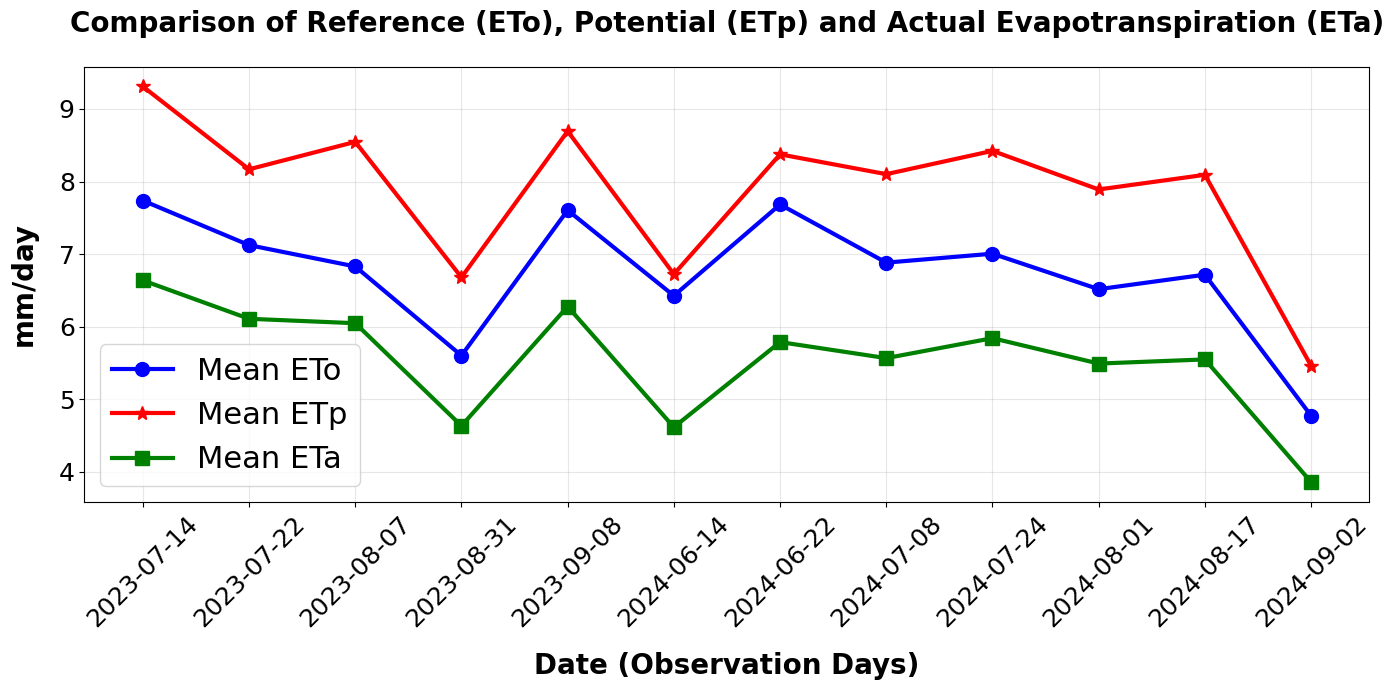

In [7]:
# A time-series line plot for comparison between ETo, ETp, and ETc
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_ETo_mm'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean ETo')
plt.plot(df['Date'], df['Mean_ETp_mm'], marker='*', markersize=10, linestyle='-', color='red', linewidth=3, label='Mean ETp')
plt.plot(df['Date'], df['Mean_ETc_mm'], marker='s', markersize=10, linestyle='-', color='green', linewidth=3, label='Mean ETa')
plt.title('Comparison of Reference (ETo), Potential (ETp) and Actual Evapotranspiration (ETa)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('mm/day', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=22)
plt.xticks(rotation=45)
save_fig("ETo_ETc_ETp_Comparison")
plt.show()

Saving figure Kcb_Ke_Comparison


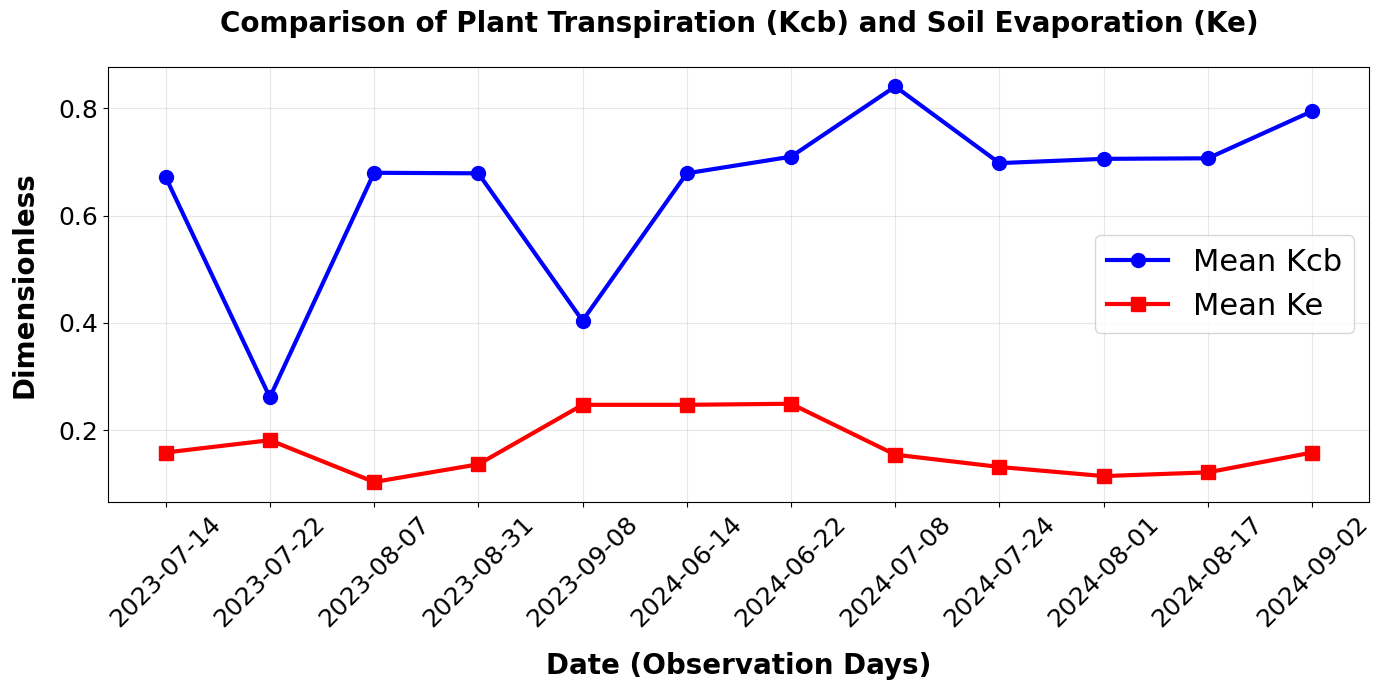

In [9]:
# A time-series line plot for comparison between Kcb and Ke
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_Kcb'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean Kcb')
plt.plot(df['Date'], df['Mean_Ke'], marker='s', markersize=10, linestyle='-', color='red', linewidth=3, label='Mean Ke')
plt.title('Comparison of Plant Transpiration (Kcb) and Soil Evaporation (Ke)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Dimensionless', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("Kcb_Ke_Comparison")
plt.show()

Saving figure Kcb_Ke_Ks_Comparison


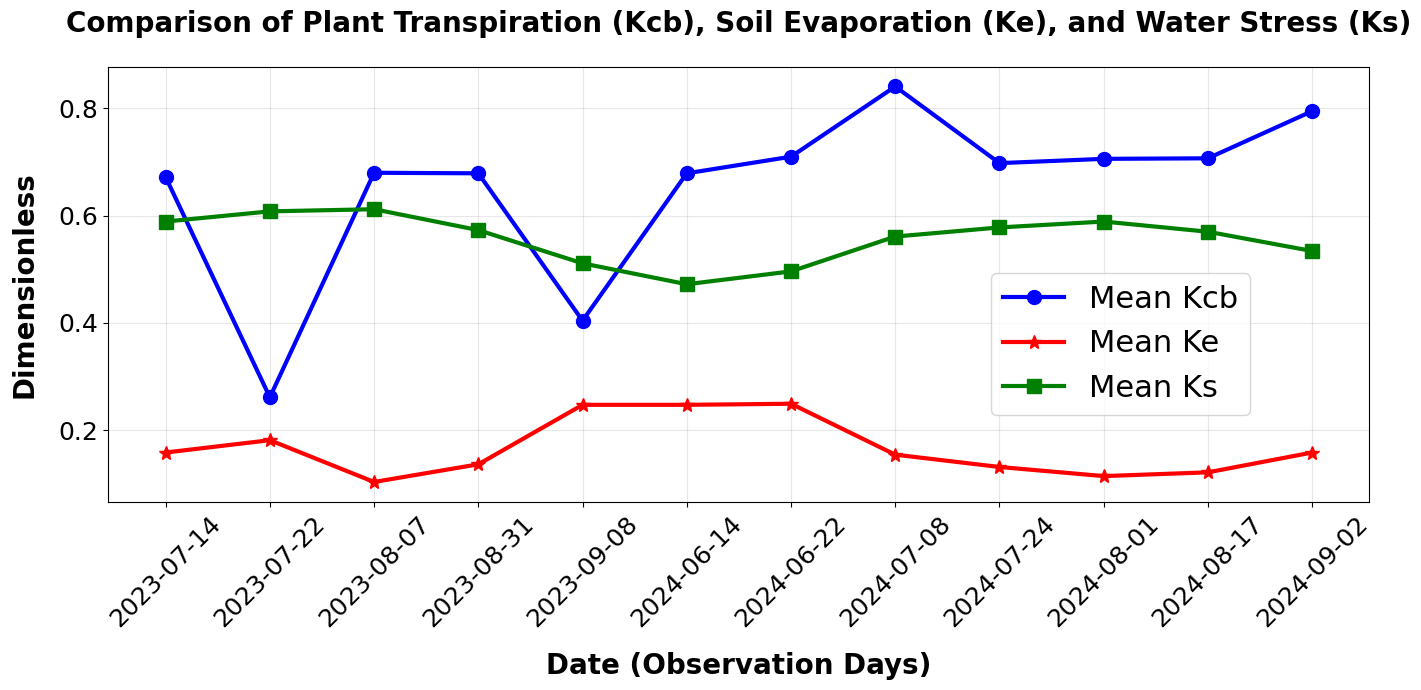

In [10]:
# A time-series line plot for comparison between Kcb, Ke, and Ks
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_Kcb'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean Kcb')
plt.plot(df['Date'], df['Mean_Ke'], marker='*', markersize=10, linestyle='-', color='red', linewidth=3, label='Mean Ke')
plt.plot(df['Date'], df['Mean_Ks'], marker='s', markersize=10, linestyle='-', color='green', linewidth=3, label='Mean Ks')
plt.title('Comparison of Plant Transpiration (Kcb), Soil Evaporation (Ke), and Water Stress (Ks)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Dimensionless', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(loc=(0.7, 0.2), fontsize=22)
plt.xticks(rotation=45)
save_fig("Kcb_Ke_Ks_Comparison")
plt.show()

Saving figure Ks_RE_Comparison


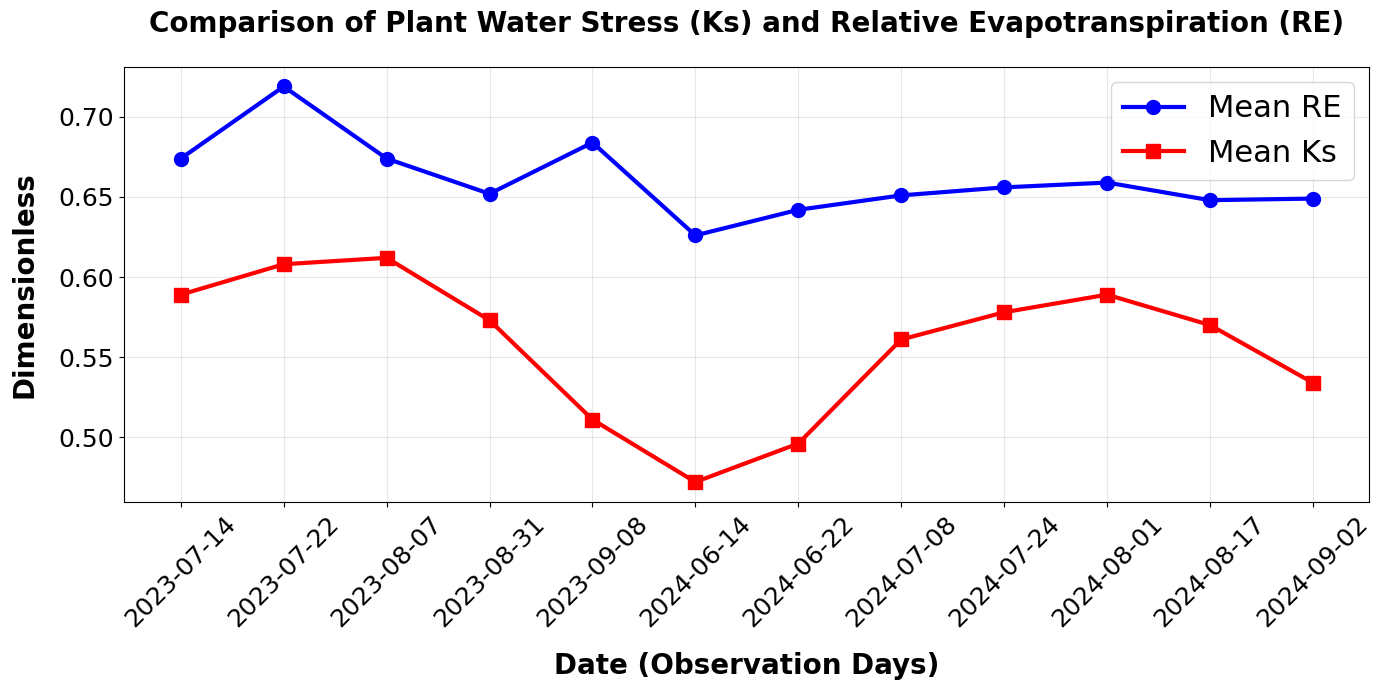

In [11]:
# A time-series line plot for comparison between Ks and RE
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_RE'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean RE')
plt.plot(df['Date'], df['Mean_Ks'], marker='s', markersize=10, linestyle='-', color='red', linewidth=3, label='Mean Ks')
plt.title('Comparison of Plant Water Stress (Ks) and Relative Evapotranspiration (RE)', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Dimensionless', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("Ks_RE_Comparison")
plt.show()

Saving figure TVDI_CWSI_Comparison


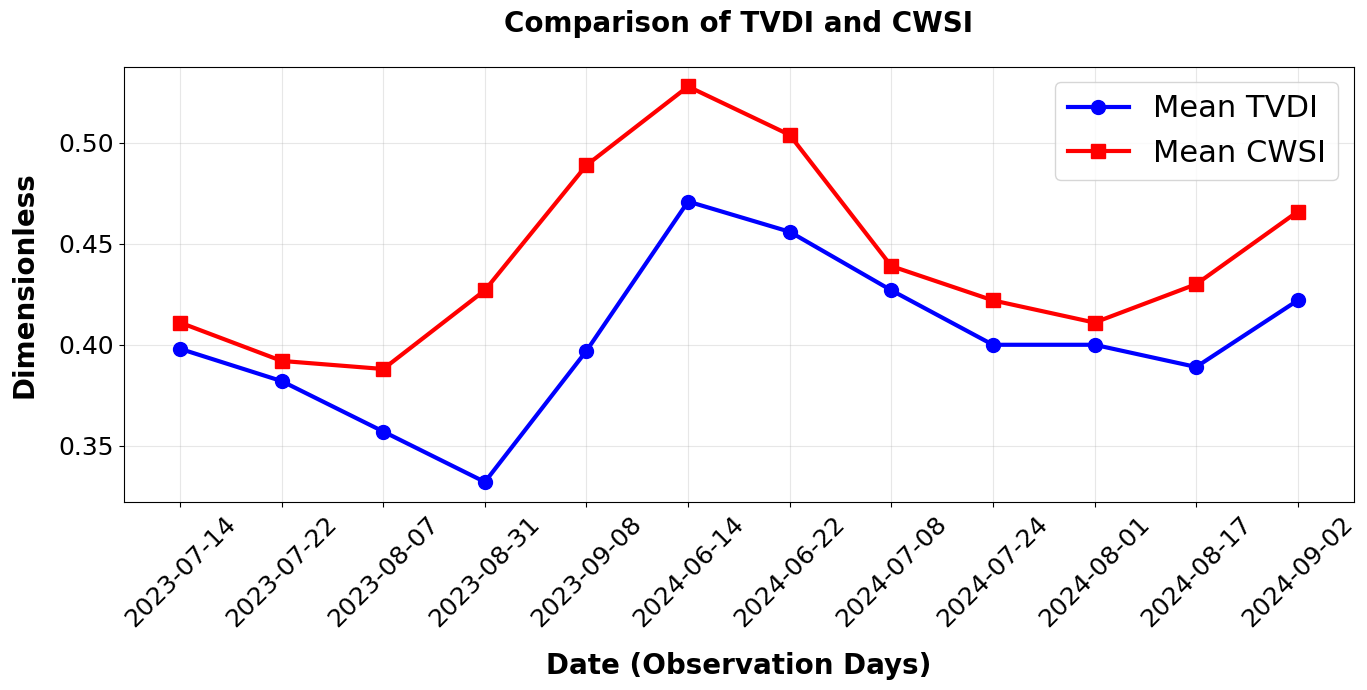

In [12]:
# A time-series line plot for comparison between CWSI and TVDI
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Mean_TVDI'], marker='o', markersize=10, linestyle='-', color='blue', linewidth=3, label='Mean TVDI')
plt.plot(df['Date'], df['Mean_CWSI'], marker='s', markersize=10, linestyle='-', color='red', linewidth=3, label='Mean CWSI')
plt.title('Comparison of TVDI and CWSI', 
          fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Date (Observation Days)', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Dimensionless', fontsize=20, fontweight='bold', labelpad=15)
plt.tick_params(axis='y', labelsize=18)
plt.tick_params(axis='x', labelsize=18)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=22)
plt.xticks(rotation=45)
save_fig("TVDI_CWSI_Comparison")
plt.show()